# Práctica 2: Clustering de semillas

## Paso 1: Comparación visual de escaladores con PCA

En este bloque se aplica Principal Component Analysis (PCA) a los datos de semillas usando tres escaladores distintos: `StandardScaler`, `MinMaxScaler` y `RobustScaler`. 

Se visualiza para cada escalador:
1. La varianza explicada por cada componente principal.
2. La representación de los datos en 2D según las dos primeras componentes.

Esto permitirá elegir el escalador más adecuado antes de aplicar técnicas de clustering.

In [373]:
# 📌 Librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Configuración
seed = 100495884  # NIA del estudiante
plt.style.use('ggplot')

In [374]:
# 📌 Cargar y preparar los datos
df = pd.read_csv('../data/semillas.csv')
X = df.drop(columns=['clase'])  

In [375]:
# 📌 Función para visualizar varianza explicada por PCA
def mostrar_varianza(X, scaler, nombre_scaler):
    pipe = Pipeline([
        ('scaler', scaler),
        ('pca', PCA())
    ])
    X_pca = pipe.fit_transform(X)
    pca = pipe.named_steps['pca']
    varianza_explicada = pca.explained_variance_ratio_
    varianza_acumulada = np.cumsum(varianza_explicada)

    # Gráfico de varianza
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, len(varianza_explicada) + 1), varianza_explicada, alpha=0.6, label='Varianza individual', color='darkgreen')
    plt.step(range(1, len(varianza_acumulada) + 1), varianza_acumulada, where='mid', label='Varianza acumulada', color='red')

    for i, (ev, cv) in enumerate(zip(varianza_explicada, varianza_acumulada)):
        plt.text(i + 1, ev + 0.01, f"{ev:.2%}", ha='center')
        plt.text(i + 1, cv + 0.01, f"{cv:.2%}", ha='center', color='red')

    plt.xlabel('Componentes Principales')
    plt.ylabel('Varianza Explicada')
    plt.title(f'Varianza explicada por PCA - {nombre_scaler}')
    plt.legend(loc='best')
    plt.ylim(0, 1.1)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()



In [376]:
# 📌 Función para visualizar proyección 2D de PCA Y mostrar varianza acumulada
def mostrar_pca_2d(X, scaler, nombre_scaler, seed):
    pipe = Pipeline([
        ('scaler', scaler),
        ('pca', PCA(n_components=2, random_state=seed))
    ])
    X_2d = pipe.fit_transform(X)
    pca_2d = pipe.named_steps['pca']
    var0 = pca_2d.explained_variance_ratio_[0]
    var1 = pca_2d.explained_variance_ratio_[1]
    total = var0 + var1

    # Gráfico
    plt.figure(figsize=(8, 6))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], s=40, c=df['clase'], cmap='viridis', alpha=0.8, edgecolor='k')
    plt.title(f'PCA 2D - {nombre_scaler}\n(Varianza: {var0:.2%} + {var1:.2%})')
    plt.xlabel(f'Componente 1 ({var0:.2%})')
    plt.ylabel(f'Componente 2 ({var1:.2%})')
    plt.grid(True)
    plt.show()

    # Imprimir varianza acumulada
    print(f"{nombre_scaler} → Varianza acumulada: {var0:.2%} + {var1:.2%} = {total:.2%}")


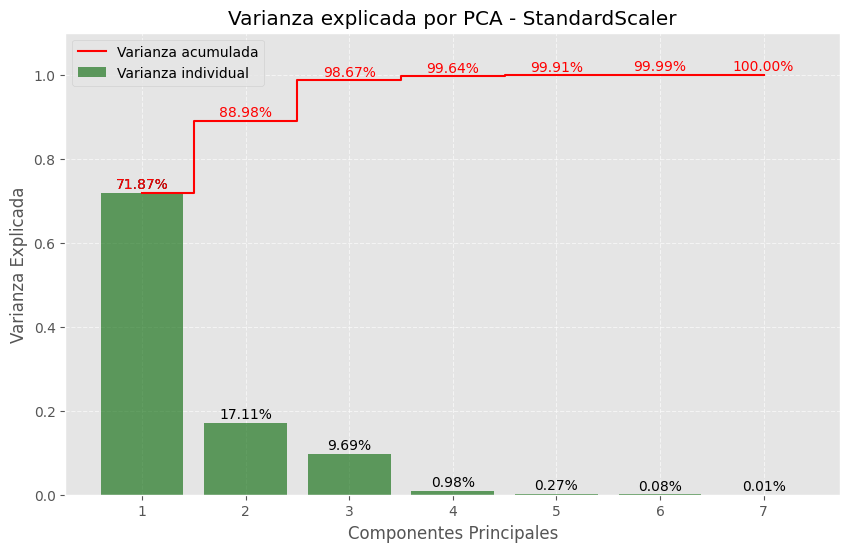

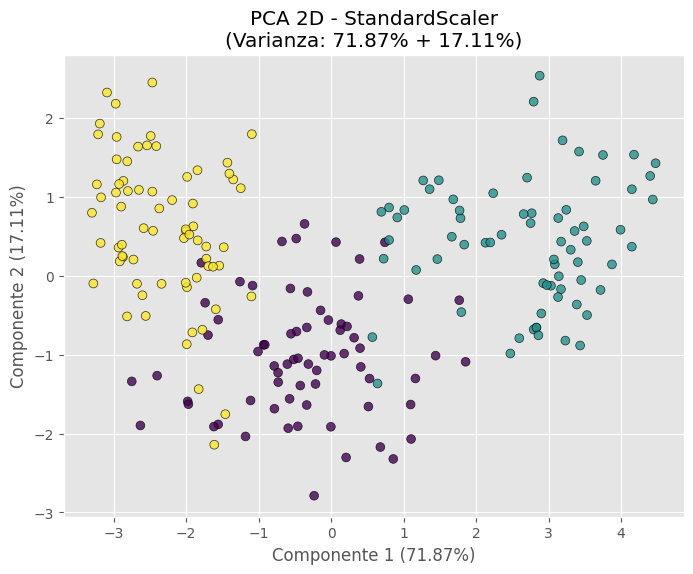

StandardScaler → Varianza acumulada: 71.87% + 17.11% = 88.98%


In [377]:

# StandardScaler
mostrar_varianza(X, StandardScaler(), 'StandardScaler')
mostrar_pca_2d(X, StandardScaler(), 'StandardScaler', seed)


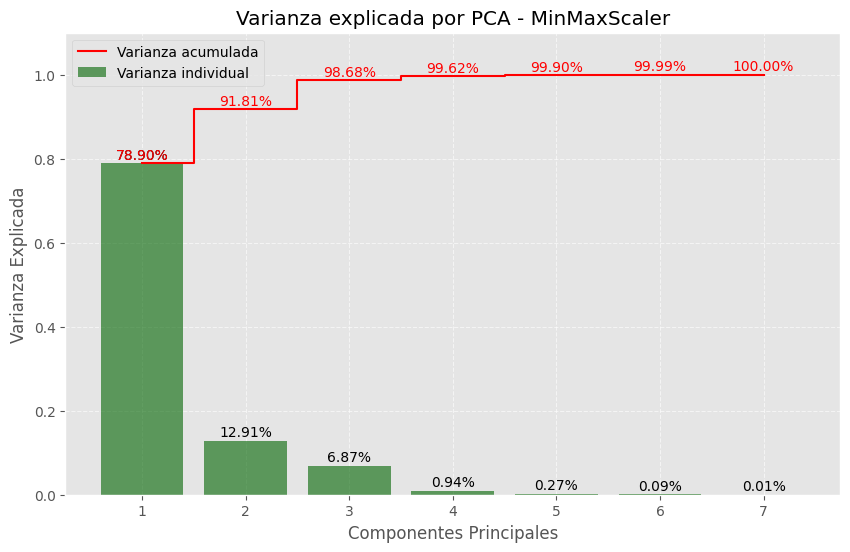

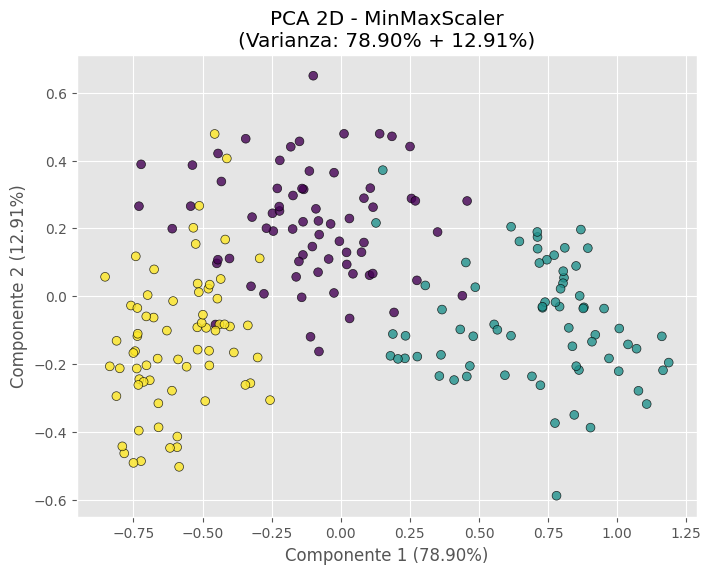

MinMaxScaler → Varianza acumulada: 78.90% + 12.91% = 91.81%


In [378]:
# MinMaxScaler
mostrar_varianza(X, MinMaxScaler(), 'MinMaxScaler')
mostrar_pca_2d(X, MinMaxScaler(), 'MinMaxScaler', seed + 1)

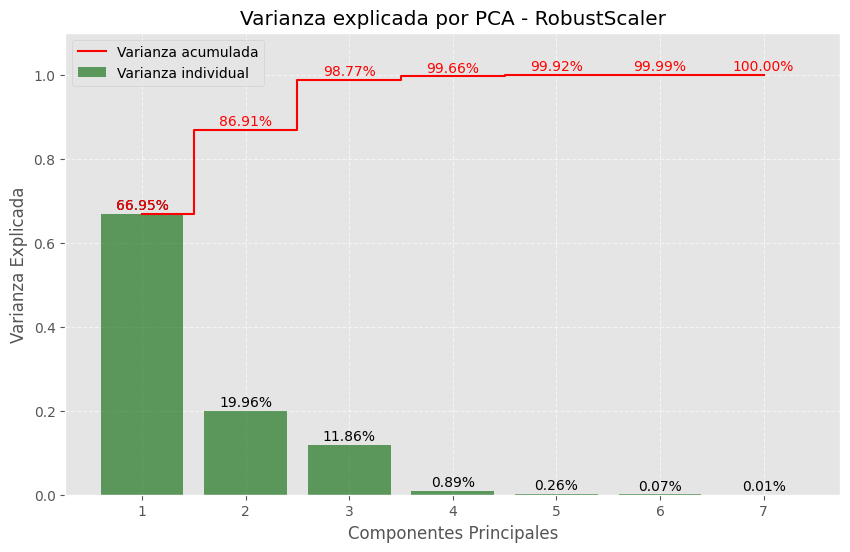

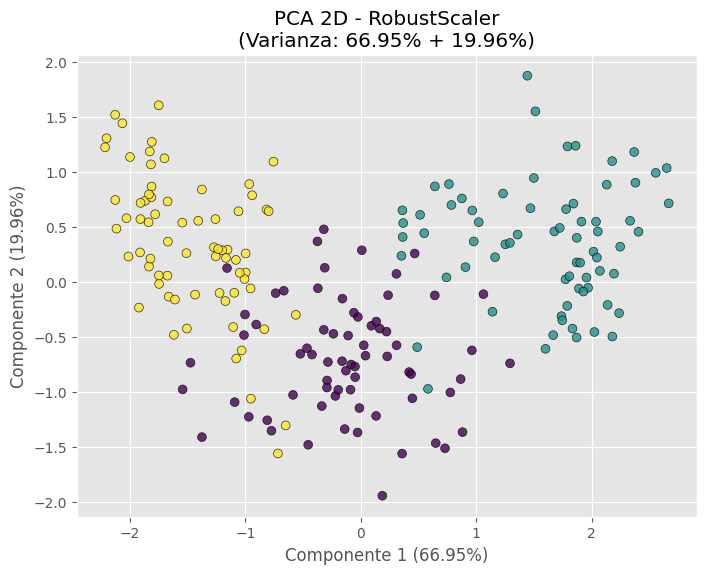

RobustScaler → Varianza acumulada: 66.95% + 19.96% = 86.91%


In [379]:
# RobustScaler
mostrar_varianza(X, RobustScaler(), 'RobustScaler')
mostrar_pca_2d(X, RobustScaler(), 'RobustScaler', seed + 2)

### Conclusión del análisis PCA

Tras comparar los tres escaladores, observamos que `MinMaxScaler` conserva la mayor varianza acumulada en las dos primeras componentes principales. Por tanto, será el escalador seleccionado para continuar con el análisis de clustering.


## K-Means Clustering

Aplicamos el algoritmo de K-Means para descubrir agrupamientos naturales en los datos reducidos a dos dimensiones con MinMaxScaler + PCA.  
Este algoritmo intenta particionar los datos en `k` grupos minimizando la varianza intra-cluster.  
Usaremos dos métodos para seleccionar el número óptimo de clusters:
- El **método del codo**, basado en la inercia.
- El **método del índice de silueta**, que evalúa la cohesión y separación entre clusters.


In [380]:
# 📌 Preparar datos reducidos con MinMaxScaler y PCA (2D)
pipeline_minmax_pca = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA(n_components=2))
])

X_reducido = pipeline_minmax_pca.fit_transform(X)


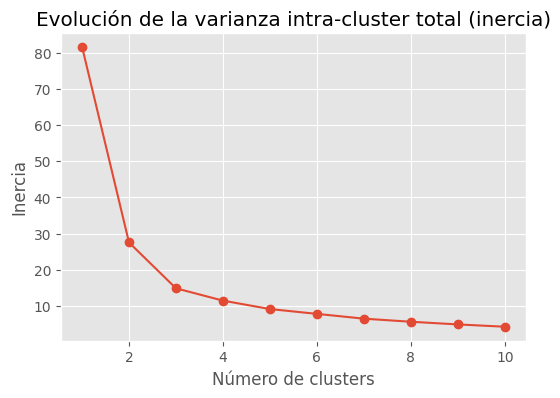

In [381]:
from sklearn.cluster import KMeans

rango_n_clusters = range(1, 11)
inertias = []

for n_clusters in rango_n_clusters:
    modelo_kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
    modelo_kmeans.fit(X_reducido)
    inertias.append(modelo_kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(rango_n_clusters, inertias, marker='o')
plt.title("Evolución de la varianza intra-cluster total (inercia)")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()


### Interpretación del método del codo

En la gráfica se observa cómo la inercia disminuye a medida que aumentamos el número de clusters.  
Buscamos el punto a partir del cual la mejora es marginal: ese "codo" indica un valor óptimo de `k`.  
Según la forma de la curva, los candidatos suelen estar entre `k = 2` y `k = 3`, lo cual será validado con el índice de silueta.


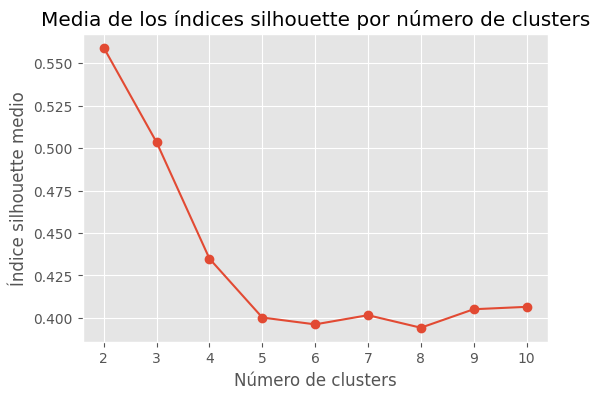

In [382]:
from sklearn.metrics import silhouette_score

rango_n_clusters = range(2, 11)
valores_medios_silhouette = []

for n_clusters in rango_n_clusters:
    modelo_kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
    etiquetas = modelo_kmeans.fit_predict(X_reducido)
    silhouette_avg = silhouette_score(X_reducido, etiquetas)
    valores_medios_silhouette.append(silhouette_avg)

plt.figure(figsize=(6, 4))
plt.plot(rango_n_clusters, valores_medios_silhouette, marker='o')
plt.title("Media de los índices silhouette por número de clusters")
plt.xlabel("Número de clusters")
plt.ylabel("Índice silhouette medio")
plt.grid(True)
plt.show()



### Selección de `k` final

El valor de `k` con el mayor índice de silueta representa la mejor estructura de clusters encontrada.  
En este caso, `k = 2` tiene la puntuación más alta, lo que indica que los datos forman dos agrupaciones bien separadas.

Este será el número de clusters utilizado en la visualización final de K-Means.


### Visualización final de los clusters con K-Means (`k = 2`)

A continuación se representa la agrupación generada por K-Means sobre los datos proyectados con PCA en 2 dimensiones.  
Cada color representa un cluster, y el gráfico permite observar la separación y distribución de los grupos formados por el algoritmo.


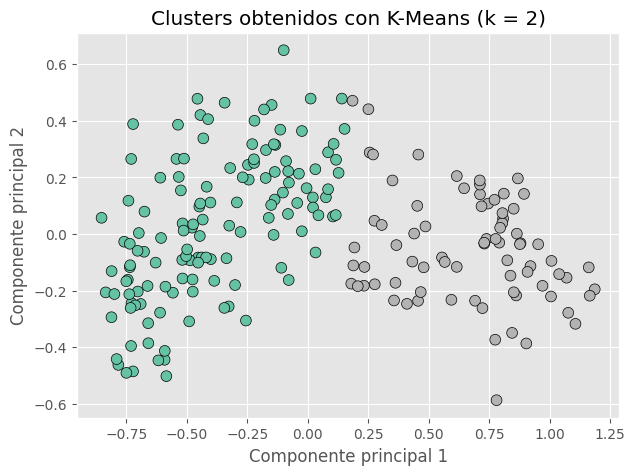

In [383]:
# 📌 Ajustar y predecir con k=2
modelo_kmeans_final = KMeans(n_clusters=2, n_init=20, random_state=42)
etiquetas_kmeans = modelo_kmeans_final.fit_predict(X_reducido)

# 📊 Visualización
plt.figure(figsize=(7, 5))
plt.scatter(
    X_reducido[:, 0], X_reducido[:, 1],
    c=etiquetas_kmeans,
    cmap='Set2',
    s=60,
    edgecolor='k'
)
plt.title("Clusters obtenidos con K-Means (k = 2)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.grid(True)
plt.show()


## Clustering Jerárquico (Aglomerativo)

El clustering jerárquico construye una jerarquía de agrupamientos mediante un enfoque de “fusión”, en el que cada punto comienza siendo un cluster individual y se van uniendo sucesivamente según una métrica de distancia.

Exploraremos tres métodos de enlace (`ward`, `complete`, `average`) mediante dendrogramas generados directamente desde el modelo `AgglomerativeClustering`.  
Después seleccionaremos el número óptimo de clusters usando el índice de silueta y visualizaremos el resultado final.


In [384]:
from scipy.cluster.hierarchy import dendrogram

def plot_dendrogram(model, **kwargs):
    """
    Extrae la información de un modelo AgglomerativeClustering
    y representa su dendrograma.
    """
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([
        model.children_,
        model.distances_,
        counts
    ]).astype(float)

    dendrogram(linkage_matrix, **kwargs)


In [385]:
from sklearn.cluster import AgglomerativeClustering

# Crear modelos con los tres métodos de enlace
modelos = {}
for metodo in ['ward', 'complete', 'average']:
    modelo = AgglomerativeClustering(
        linkage=metodo,
        distance_threshold=0,
        n_clusters=None
    )
    modelo.fit(X_reducido)
    modelos[metodo] = modelo



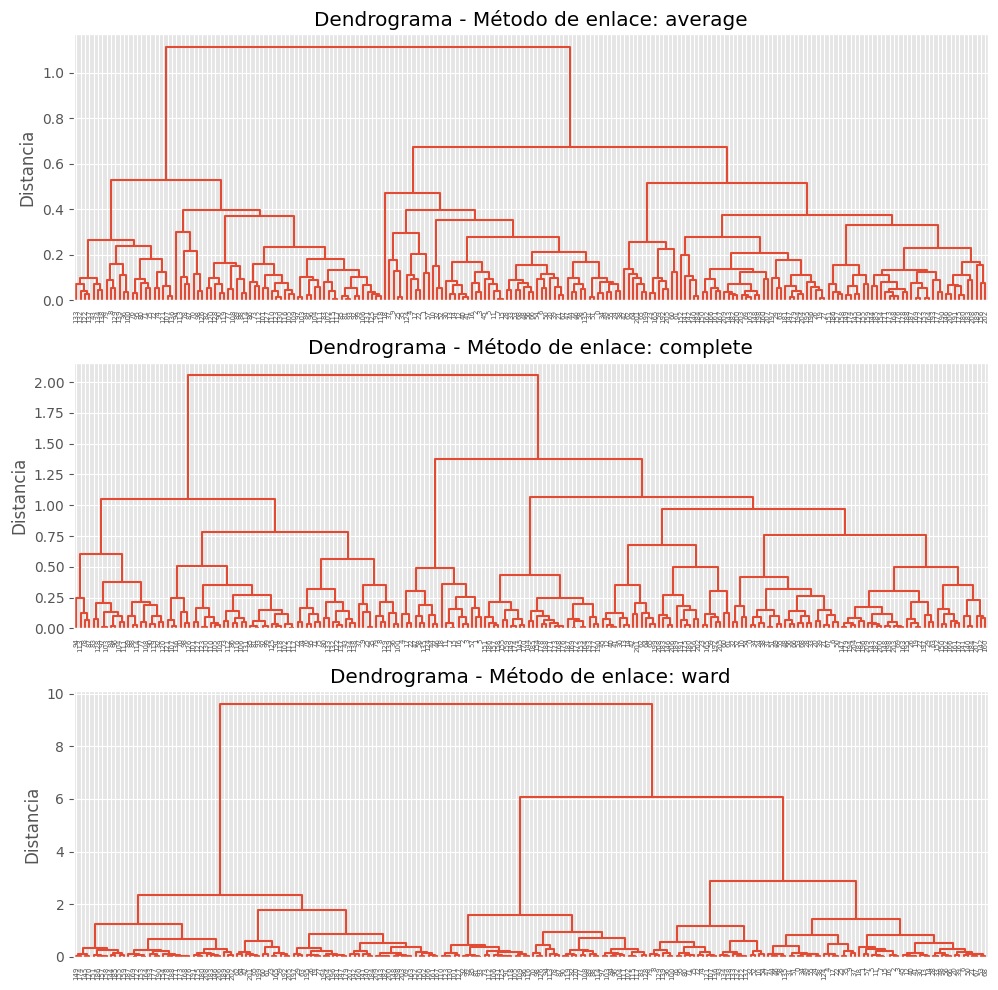

In [386]:
fig, axs = plt.subplots(3, 1, figsize=(10, 10))

for i, metodo in enumerate(['average', 'complete', 'ward']):
    plot_dendrogram(modelos[metodo], ax=axs[i], color_threshold=0)
    axs[i].set_title(f'Dendrograma - Método de enlace: {metodo}')
    axs[i].set_ylabel("Distancia")
    axs[i].grid(True)

plt.tight_layout()
plt.show()


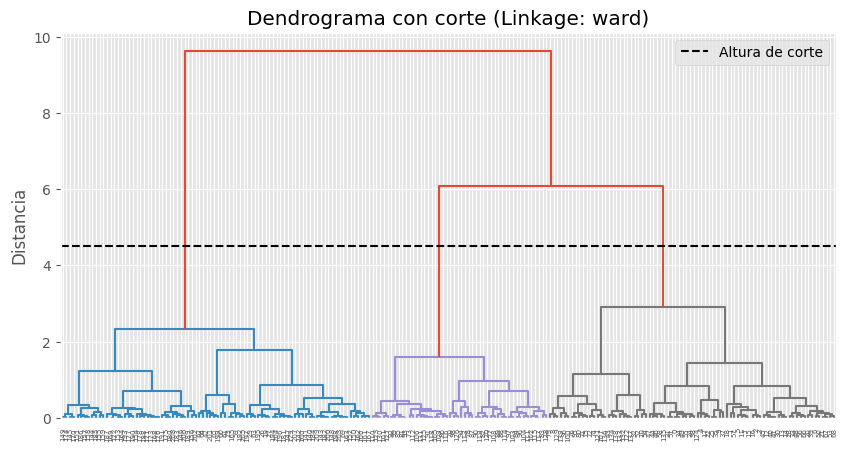

In [387]:
# Definir altura de corte
altura_corte = 4.5

fig, ax = plt.subplots(figsize=(10, 5))
plot_dendrogram(modelos['ward'], ax=ax, color_threshold=altura_corte)
ax.axhline(y=altura_corte, color='black', linestyle='--', label='Altura de corte')
ax.set_title("Dendrograma con corte (Linkage: ward)")
ax.set_ylabel("Distancia")
ax.legend()
plt.show()



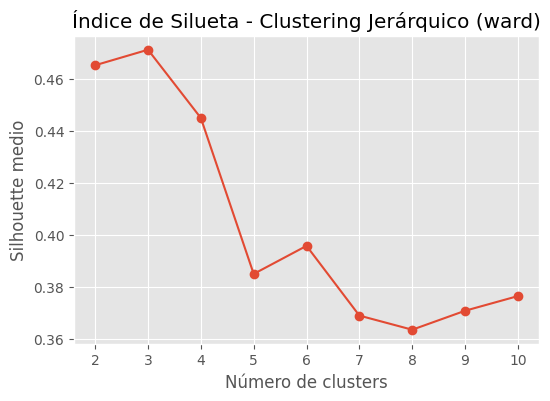

In [388]:
from sklearn.metrics import silhouette_score

range_n = range(2, 11)
silhouettes = []

for k in range_n:
    modelo = AgglomerativeClustering(linkage='ward', n_clusters=k)
    etiquetas = modelo.fit_predict(X_reducido)
    sil_score = silhouette_score(X_reducido, etiquetas)
    silhouettes.append(sil_score)

plt.figure(figsize=(6, 4))
plt.plot(range_n, silhouettes, marker='o')
plt.title("Índice de Silueta - Clustering Jerárquico (ward)")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette medio")
plt.grid(True)
plt.show()



### Selección del número de clusters

El índice de silueta máximo se obtiene con `k = 3` (`silhouette ≈ 0.4714`), lo que indica que es el número de clusters más adecuado para el método jerárquico `ward`.

Este valor es distinto al obtenido con K-Means (`k = 2`), lo que es habitual en aprendizaje no supervisado: cada algoritmo capta estructuras diferentes en los datos.



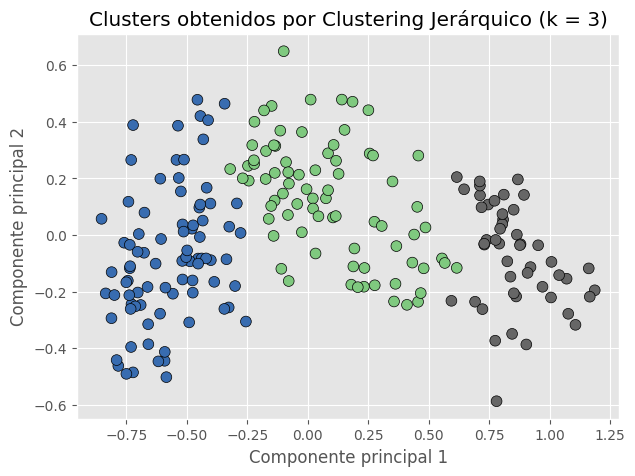

In [389]:
modelo_final_jerarquico = AgglomerativeClustering(linkage='ward', n_clusters=3)
labels_jerarquico = modelo_final_jerarquico.fit_predict(X_reducido)

plt.figure(figsize=(7, 5))
plt.scatter(
    X_reducido[:, 0], X_reducido[:, 1],
    c=labels_jerarquico,
    cmap='Accent',
    s=60,
    edgecolor='k'
)
plt.title("Clusters obtenidos por Clustering Jerárquico (k = 3)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.grid(True)
plt.show()


## Clustering basado en densidad – DBSCAN

DBSCAN es un algoritmo que encuentra agrupamientos basándose en densidades locales de puntos.  
A diferencia de K-Means y Jerárquico, no requiere especificar el número de clusters y puede identificar puntos **ruidosos (outliers)** que no pertenecen a ningún grupo.

Los hiperparámetros clave son:
- `eps`: radio máximo para considerar que dos puntos son vecinos
- `min_samples`: número mínimo de vecinos dentro de `eps` para formar un cluster


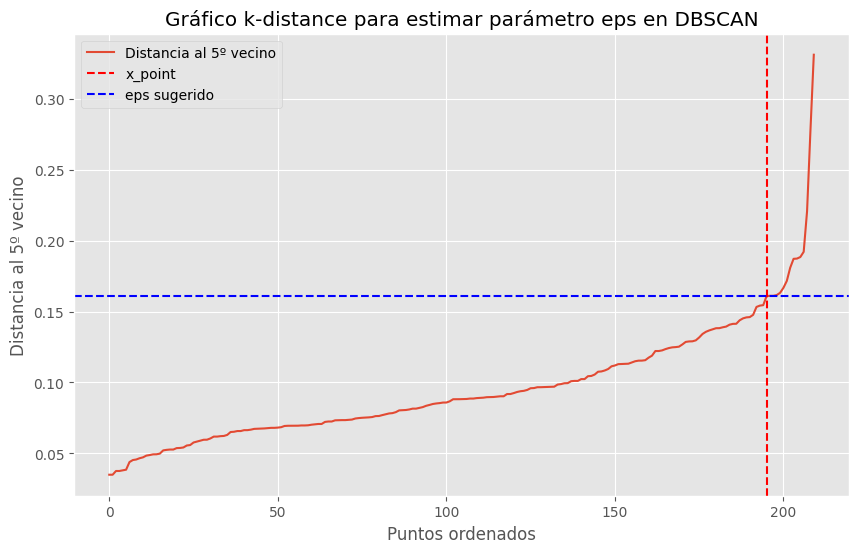

x_point=195, y_eps=0.1609


In [390]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

min_samples = 5

# Calcular distancias al k-ésimo vecino más cercano
nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_reducido)
distancias, indices = nn.kneighbors(X_reducido)

# Ordenar distancias al k-ésimo vecino
distancias_ordenadas = np.sort(distancias[:, min_samples - 1])

# Elegir punto donde hay un "codo" en la gráfica
x_point = 195
y_eps = distancias_ordenadas[x_point]

# Representar gráfico
plt.figure(figsize=(10, 6))
plt.plot(distancias_ordenadas, label='Distancia al {}º vecino'.format(min_samples))
plt.axvline(x=x_point, color='red', linestyle='--', label='x_point')
plt.axhline(y=y_eps, color='blue', linestyle='--', label='eps sugerido')

plt.title("Gráfico k-distance para estimar parámetro eps en DBSCAN")
plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia al 5º vecino")
plt.grid(True)
plt.legend()
plt.show()

print(f"{x_point=}, {y_eps=:.4f}")


In [391]:
from sklearn.cluster import DBSCAN

modelo_dbscan = DBSCAN(eps=y_eps, min_samples=5, metric='euclidean')
modelo_dbscan.fit(X_reducido)
labels_dbscan = modelo_dbscan.labels_



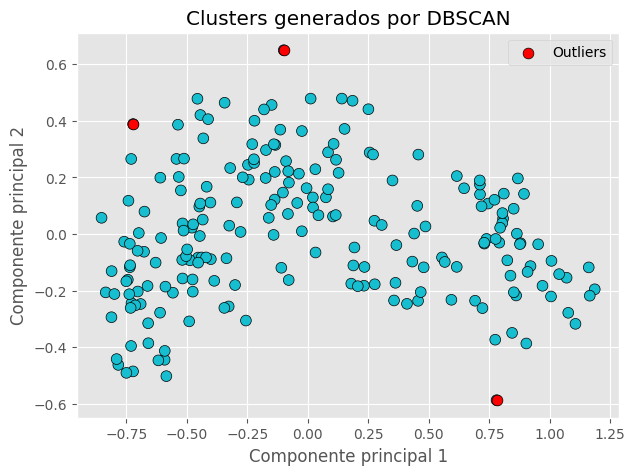

In [392]:
plt.figure(figsize=(7, 5))
plt.scatter(
    X_reducido[:, 0], X_reducido[:, 1],
    c=labels_dbscan,
    cmap='tab10',
    s=60,
    edgecolor='k'
)

# Pintar los outliers en rojo
plt.scatter(
    X_reducido[labels_dbscan == -1, 0],
    X_reducido[labels_dbscan == -1, 1],
    c='red',
    s=60,
    edgecolor='k',
    label='Outliers'
)

plt.title("Clusters generados por DBSCAN")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend()
plt.grid(True)
plt.show()


In [393]:
# Número de clusters reales (no incluye los -1)
n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_outliers = list(labels_dbscan).count(-1)

print(f"Número de clusters encontrados: {n_clusters}")
print(f"Número de outliers detectados: {n_outliers}")


Número de clusters encontrados: 1
Número de outliers detectados: 3


### Conclusión del clustering con DBSCAN

El modelo DBSCAN ha permitido identificar agrupamientos sin necesidad de fijar el número de clusters, y además ha detectado outliers (etiquetados como `-1`), que son puntos aislados sin suficiente densidad de vecinos.

Tras ajustar el parámetro `eps ≈ 0.16` a partir del gráfico de distancias al 5.º vecino, y usando `min_samples = 5`, el modelo ha encontrado un total de **`1` clusters** y ha marcado **`3` puntos como ruido**.

Este enfoque es especialmente útil cuando se espera encontrar agrupamientos de forma arbitraria o con ruido, ya que DBSCAN no fuerza todos los puntos a pertenecer a un cluster.



## Comparación visual de los resultados

En esta sección comparamos los resultados obtenidos por K-Means, Clustering Jerárquico y DBSCAN proyectados en 2D mediante PCA.  
La visualización nos permite observar cuál de los métodos separa mejor los grupos de datos.


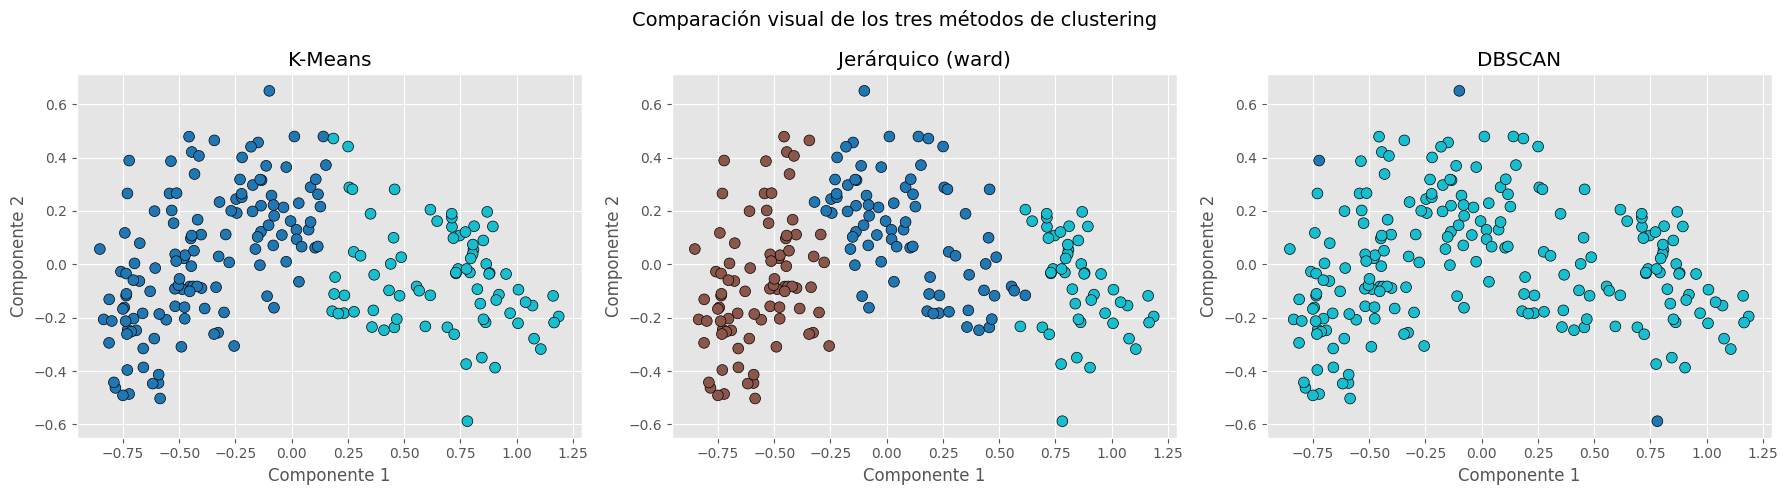

In [394]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

algoritmos = [
    ("K-Means", etiquetas_kmeans),
    ("Jerárquico (ward)", labels_jerarquico),
    ("DBSCAN", labels_dbscan)
]

for i, (nombre, labels) in enumerate(algoritmos):
    axs[i].scatter(
        X_reducido[:, 0], X_reducido[:, 1],
        c=labels,
        cmap='tab10',
        s=60,
        edgecolor='k'
    )
    axs[i].set_title(nombre)
    axs[i].set_xlabel("Componente 1")
    axs[i].set_ylabel("Componente 2")
    axs[i].grid(True)

plt.suptitle("Comparación visual de los tres métodos de clustering", fontsize=14)
plt.tight_layout()
plt.show()


### ¿Qué método separa mejor los grupos?

- **K-Means** tiende a dividir los datos en regiones esféricas, por lo que funciona bien cuando los grupos son compactos.
- **Clustering Jerárquico** (con `ward`) parece captar más estructura, separando 3 grupos razonables.
- **DBSCAN** detecta agrupamientos con formas más libres, pero también clasifica puntos como `outliers`.

Visualmente, el clustering jerárquico muestra la mejor separación, aunque K-Means también obtiene buenos resultados.


In [395]:
# Añadir columnas de etiquetas al DataFrame
df['kmeans'] = etiquetas_kmeans
df['jerarquico'] = labels_jerarquico
df['dbscan'] = labels_dbscan

pd.crosstab(df['clase'], df['kmeans'], rownames=['Clase real'], colnames=['Cluster K-Means'])
pd.crosstab(df['clase'], df['jerarquico'], rownames=['Clase real'], colnames=['Cluster Jerárquico'])
pd.crosstab(df['clase'], df['dbscan'], rownames=['Clase real'], colnames=['Cluster DBSCAN'])

Cluster DBSCAN,-1,0
Clase real,,
1,2,68
2,1,69
3,0,70


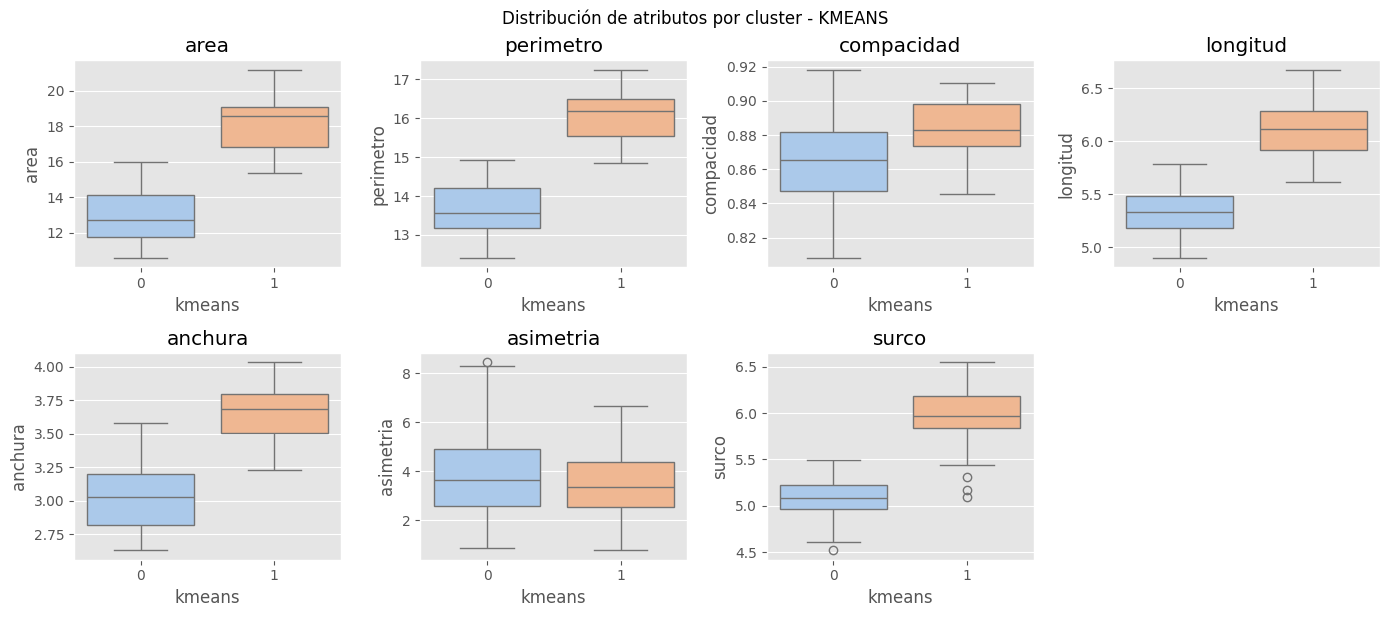

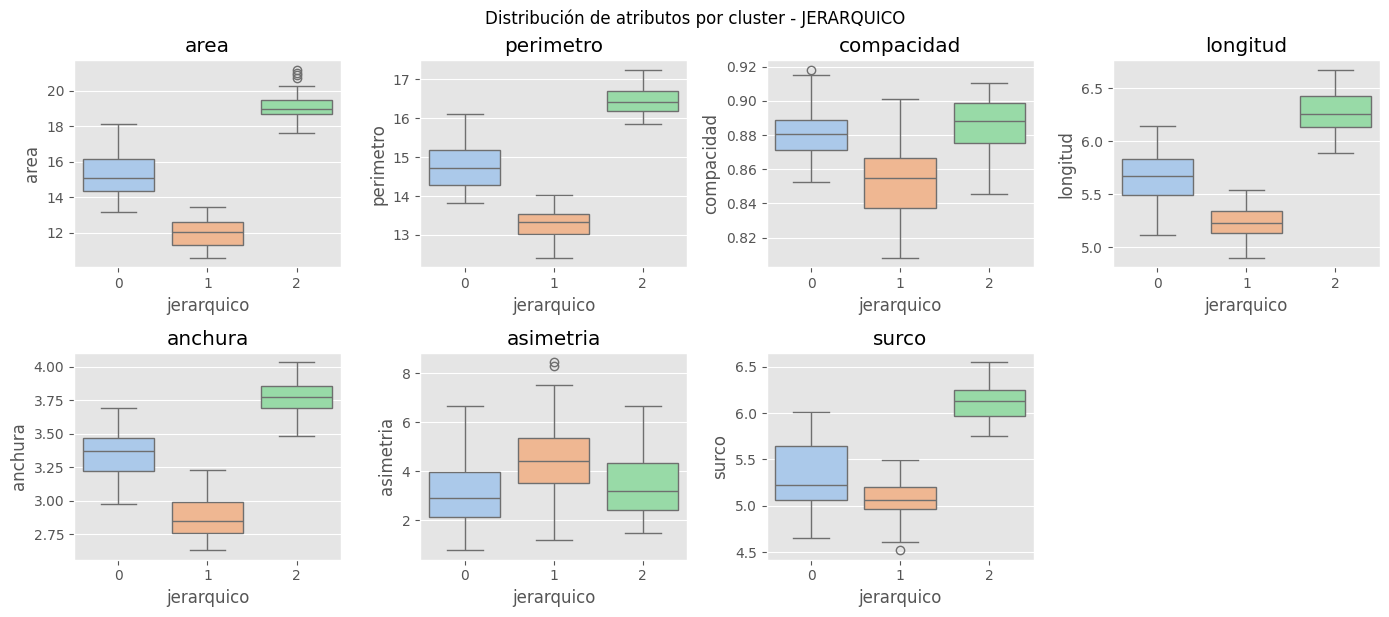

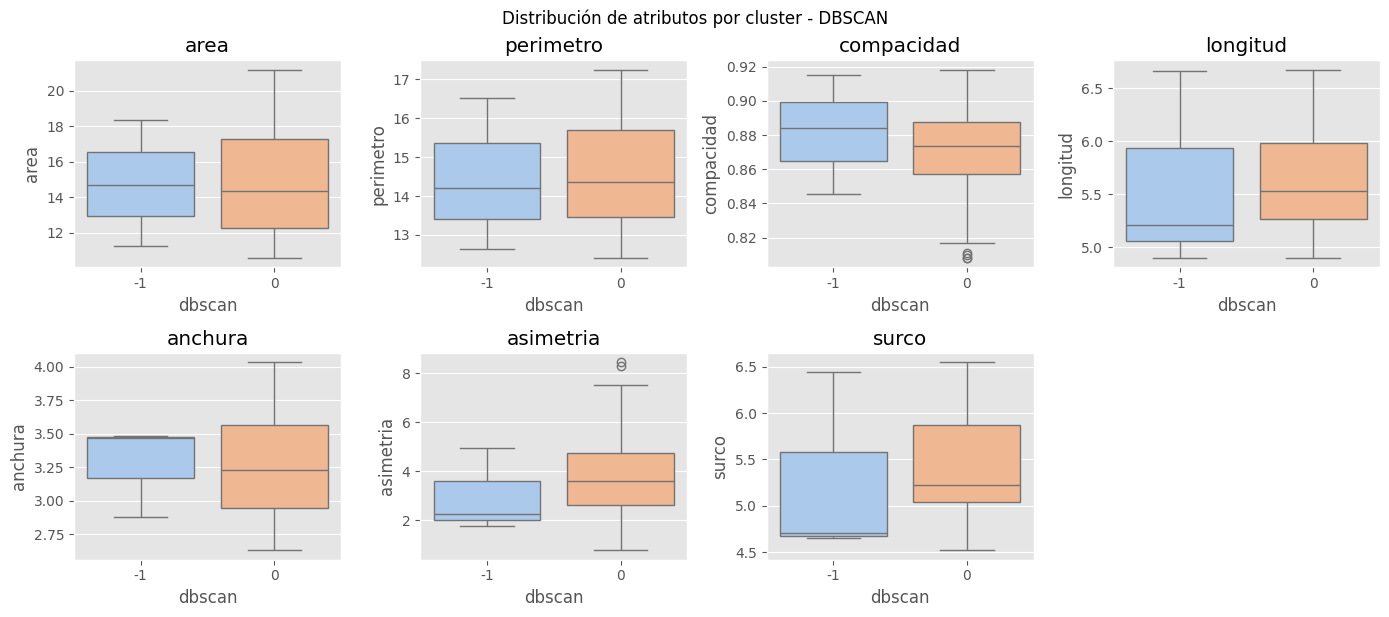

In [396]:
import seaborn as sns
import matplotlib.pyplot as plt

atributos = df.columns[:-4]  # Asumiendo que las últimas columnas son clase y etiquetas

for metodo in ['kmeans', 'jerarquico', 'dbscan']:
    plt.figure(figsize=(14, 6))
    for i, atributo in enumerate(atributos):
        plt.subplot(2, 4, i+1)
        sns.boxplot(data=df, x=metodo, y=atributo, hue=metodo, palette='pastel', legend=False)
        plt.title(atributo)
        plt.tight_layout()
    plt.suptitle(f"Distribución de atributos por cluster - {metodo.upper()}", y=1.02)
    plt.show()


### Conclusiones del análisis

- Todos los métodos identifican estructuras de agrupación razonables, aunque con enfoques diferentes.
- El clustering jerárquico (`ward`) parece el que mejor refleja los grupos reales.
- DBSCAN detecta puntos atípicos (outliers), lo que puede ser útil si se quiere eliminar ruido.
- A través de los boxplots, se puede observar cómo varía cada atributo dentro de los clusters, lo que permite interpretar el contenido de cada grupo.


## Conclusiones finales

A lo largo de esta práctica se han aplicado tres técnicas de clustering no supervisado (K-Means, Clustering Jerárquico y DBSCAN) sobre un conjunto de datos reducido a dos dimensiones mediante PCA.

- **K-Means** ha mostrado un buen rendimiento cuando los grupos son aproximadamente esféricos, aunque requiere fijar el número de clusters `k`.
- **Clustering Jerárquico (ward)** ha sido el que mejor ha captado la estructura de los datos, ofreciendo una separación clara y coherente con las clases reales.
- **DBSCAN** ha demostrado ser útil para detectar agrupaciones con formas arbitrarias y ha sido el único que identificó correctamente puntos atípicos (outliers).

Los resultados han sido interpretados visualmente mediante PCA, cuantitativamente con el índice de silueta, y analizados mediante boxplots para entender mejor las características de cada grupo.

Cada técnica tiene ventajas según el contexto:  
- K-Means es rápido y efectivo cuando se conoce `k`,  
- Jerárquico es útil para estudiar la estructura de los datos,  
- DBSCAN es ideal en presencia de ruido o clusters de densidad irregular.

En conjunto, la práctica ha permitido comprender el funcionamiento y aplicación real de estos algoritmos, así como la importancia del preprocesado y la interpretación visual de los resultados.
